# Backpropagation, Gradient Descent & Optimizers

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:

1. [Introduction](#intro)
2. [Section 1 — The Training Loop in One Picture ](#section1)
3. [Section 2 — Gradient Descent](#section2)
4. [Section 3 — The Learning Rate](#section3)
5. [Section 4 - Backpropagation](#section4)
6.  [Section 5 - Optimizers, Epochs, and Batches](#section5)
7. [Section 6 - Hands-On Lab: Understanding Training](#section6)
8. [References](#refs)

### Learning Objectives Of This Notebook
- Describe the four-step training loop of a neural network.
- Explain gradient descent and the role of the learning rate.
- Explain backpropagation conceptually and name common optimizers, epochs, and batches.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction

Training a neural network is not simply about building its layers and making predictions. The model must also learn from its mistakes and continuously adjust its weights to improve its performance.

In this notebook, we explore the core concepts behind this learning process, including the **training loop, Gradient Descent, learning rate, backpropagation, optimizers, epochs, and batches**. We will also experiment with different learning rates to observe how they affect the model's training and loss over time.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : The Training Loop in One Picture

> Training a neural network is an iterative process. Instead of learning everything at once, the network repeatedly goes through the data, measures its mistakes, and gradually adjusts itself to make better predictions. This process is called the **training loop**, and it consists of four main steps:

 > <div style="text-align: center;"> <img src="training loop.PNG" alt="training loop " width="500" > </div>




### 1. Forward Pass — Make Predictions

The process begins with the **forward pass**. The input data is passed through the neural network, moving from the input layer through the hidden layers until it reaches the output layer.

At each layer, the network uses its current **weights and biases** to transform the input. Activation functions are then applied to introduce non-linearity and allow the network to learn more complex patterns.

The final result is the network's **prediction**.

> **Input → Hidden Layers → Output → Prediction**

At the beginning of training, the weights are usually initialized randomly, so the predictions are often inaccurate.

---------------

### 2. Compute the Loss — Measure the Error

Next, the network compares its prediction with the **actual or correct value**, known as the target.

A **loss function** is used to measure how far the prediction is from the correct answer. The resulting value is called the **loss**.

* A **high loss** means the network's predictions are far from the correct values.
* A **low loss** means the predictions are closer to the correct values.

The loss gives the network a clear objective: **adjust the weights in a way that reduces this error**.


---------------

### 3. Backpropagation — Find Where the Error Came From

Once the loss is calculated, the network needs to determine **how each weight contributed to that error**.

This is the role of **backpropagation**.

Backpropagation works backward through the network, starting from the output layer and moving toward the earlier layers. Using the **chain rule from calculus**, it calculates the **gradient** of the loss with respect to each weight.

In simple terms, the gradient tells us:

* Which weights contributed to increasing the loss.
* How strongly each weight affected the loss.
* In which direction each weight should be adjusted to reduce the error.

So, backpropagation answers the question:

> **"Which weights are responsible for the mistake, and how should they change?"**
>
---------------

### 4. Update the Weights — Learn from the Error

Finally, the gradients calculated during backpropagation are used to update the network's weights. This is where an optimization algorithm, such as **Gradient Descent**, is used.

The weights are adjusted slightly in the direction that reduces the loss:

> **New Weight = Old Weight − Learning Rate × Gradient**

The **learning rate** controls how large each adjustment should be:

* If it is too large, the model may make overly large steps and miss the optimal solution.
* If it is too small, learning may become very slow.

After the weights are updated, the network has learned a small amount from its previous mistake.

---------------

### The Loop Repeats

These four steps are repeated again and again:

> **Forward Pass → Calculate Loss → Backpropagation → Update Weights → Repeat**

Over thousands of iterations, the network gradually improves. The randomly initialized weights are continuously adjusted, allowing the model to reduce its loss and learn patterns from the training data.

This continuous cycle of **predicting, measuring errors, calculating gradients, and updating weights** is the core learning process of a neural network.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : Gradient Descent

> Gradient Descent is the process used to **update the weights of a neural network and reduce its loss**. After the forward pass calculates the prediction, the loss function measures the error, and backpropagation calculates the gradients, Gradient Descent uses this information to decide how the weights should change.



### Understanding the Gradient

 > <div style="text-align: center;"> <img src="gradient.PNG" alt="Gradient Descent" width="500" > </div>


A **gradient** tells us how the loss changes when a particular weight changes. More specifically, it tells us the direction of the **steepest increase** in the loss.

Therefore, if we want to **reduce** the loss, we should move in the **opposite direction of the gradient**.

This is the main idea behind Gradient Descent:

> **The gradient points uphill, so Gradient Descent moves downhill.**

The weight update can be represented as:

**New Weight = Old Weight − Learning Rate × Gradient**

The **learning rate** controls the size of each step. Instead of making one large adjustment, the network usually takes many small steps, gradually moving toward a combination of weights that produces a lower loss.

### The Foggy Hillside Intuition

Imagine that you are standing somewhere on a foggy hillside, but you cannot see the entire landscape around you. Your goal is to reach the lowest point in the valley.

Since you cannot see where the valley is, you first examine the ground around you and determine which direction goes **most steeply uphill**. Then, to move downward, you take a small step in the **opposite direction**.

You repeat this process:

1. Determine the direction of steepest increase.
2. Move a small step in the opposite direction.
3. Check your new position.
4. Repeat until you reach a point where the loss can no longer be significantly reduced.

In a neural network, the **hillside represents the loss surface**, your **position represents the current values of the weights**, and the **height represents the loss**.

The goal of Gradient Descent is to gradually adjust the weights and move from a region of **high loss** toward a region of **lower loss**, allowing the neural network to make increasingly accurate predictions.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : The Learning Rate

The **learning rate** controls how large each step is when Gradient Descent updates the weights. It determines **how quickly and how aggressively the neural network learns** from its errors.

 > <div style="text-align: center;"> <img src="ggg.jpg" alt="The Learning Rate" width="500" > </div>



Recall the weight update rule:

**New Weight = Old Weight − Learning Rate × Gradient**

The learning rate acts as a multiplier for the gradient. Even if the gradient tells us the correct direction to move, the learning rate determines **how far we move in that direction**.

Choosing an appropriate learning rate is extremely important because it directly affects how well and how efficiently the model learns.

| Learning Rate  | Effect                                                                                                                                                       |
| -------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Too high**   | Takes very large steps and may overshoot the minimum. The loss may bounce around, become unstable, or even diverge instead of decreasing.                    |
| **Too low**    | Takes extremely small steps. The model may eventually learn, but training becomes very slow and may require many iterations to make meaningful progress.     |
| **Just right** | Takes steps that are large enough to learn efficiently but small enough to move steadily toward a minimum. The loss decreases in a stable and efficient way. |

### The Intuition

Returning to the **foggy hillside analogy**, imagine that you are trying to walk downhill toward the lowest point:

* With a **very high learning rate**, you take huge steps and might walk past the valley, repeatedly jumping from one side to another without reaching the bottom.
* With a **very low learning rate**, you take tiny steps. You are moving in the correct direction, but it may take an extremely long time to reach the valley.
* With a **well-chosen learning rate**, you take reasonably sized steps that allow you to move downhill efficiently and steadily.

Therefore, the learning rate creates a balance between **speed and stability**. A good learning rate allows the model to reduce its loss efficiently without making unstable updates.

Because it is chosen before training rather than learned directly from the data, the learning rate is considered a **hyperparameter**. Finding an appropriate value is one of the most important parts of training a neural network.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section4"></a>
# Section 4 : Backpropagation

**Backpropagation**, short for **backward propagation of errors**, is the algorithm used to calculate the gradients needed to train a neural network. Its main purpose is to determine **how much each weight in the network contributed to the final error**.

After the network completes a forward pass and calculates the loss, it knows **how wrong its prediction is**, but it still needs to answer an important question:

> **Which weights were responsible for this error, and how should they be changed?**

Backpropagation answers this question.

### Working Backward Through the Network

As the name suggests, backpropagation works **backward** through the neural network.

During the forward pass, information flows like this:

> **Input → Hidden Layers → Prediction → Loss**

During backpropagation, the error information flows in the opposite direction:

> **Loss → Output Layer → Hidden Layers → Earlier Layers**

Starting from the loss, backpropagation calculates how changes in each part of the network affect the final error. It continues layer by layer until it has calculated a gradient for every trainable weight and bias.

### The Role of the Chain Rule

Backpropagation uses the **chain rule from calculus** to calculate these gradients efficiently.

A neural network is made up of a sequence of operations. For example, an input affects a neuron, the neuron affects an activation, the activation affects the next layer, and eventually all of these operations affect the final loss.

The chain rule allows backpropagation to work through these connected operations and determine:

> **How does changing this specific weight affect the final loss?**

This information is represented by the **gradient**.

A large gradient generally means that a small change in that weight can have a significant effect on the loss, while a small gradient means that the weight currently has less influence on the loss.

### Backpropagation as "Assigning Blame"

A useful way to understand backpropagation is to think of it as **assigning responsibility for the error**.

The network makes a prediction and measures how wrong it was. Backpropagation then works backward and determines how much each weight contributed to that mistake.

It is essentially asking every weight:

> **"How much did you contribute to the final error?"**

Once this information is calculated, **Gradient Descent** uses the gradients to update the weights in the direction that reduces the loss.

### Do We Calculate Backpropagation Manually?

In practice, you usually do **not** calculate backpropagation by hand. Deep learning frameworks automatically perform these calculations using **automatic differentiation**.

For example:

* **PyTorch** uses `autograd`.
* **TensorFlow** uses `GradientTape`.

These tools automatically track the operations performed during the forward pass and then calculate the required gradients during the backward pass.

However, even though the framework performs the calculations automatically, understanding what happens conceptually is essential:

> **Backpropagation calculates how responsible each weight is for the error, and Gradient Descent uses that information to update the weights and reduce the loss.**

Together, they form the core learning mechanism of a neural network.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section5"></a>
# Section 5 : Optimizers, Epochs, and Batches

Training a neural network involves more than simply calculating gradients and updating weights. To understand how the training process is organized, it is important to understand three key concepts: **optimizers, epochs, and batches**.

| Term          | Meaning                                                                                                         |
| ------------- | --------------------------------------------------------------------------------------------------------------- |
| **Optimizer** | The algorithm responsible for using the calculated gradients to update the model's weights and reduce the loss. |
| **Epoch**     | One complete pass through the entire training dataset.                                                          |
| **Batch**     | A smaller subset of the training data processed together before the model updates its weights.                  |

### 1. Optimizers

An **optimizer** is the algorithm responsible for applying the learning process. After backpropagation calculates the gradients, the optimizer uses those gradients to determine **how the weights should be updated**.

The simplest approach is **Stochastic Gradient Descent (SGD)**, which updates the weights by moving them in the direction that reduces the loss.

However, modern deep learning often uses more advanced optimizers, such as **Adam**.

**Adam** is a popular optimizer because it does more than simply apply the same learning rate to every weight. It adapts the updates based on the gradients during training, allowing different weights to effectively have different step sizes.

For many deep learning problems, **Adam is a strong and reliable starting point**.

---

### 2. Epochs

An **epoch** represents **one complete pass through the entire training dataset**.

For example, imagine a training dataset containing **10,000 samples**. If the neural network processes all 10,000 samples once, it has completed **one epoch**.

Training usually requires multiple epochs because the model does not learn everything after seeing the data only once.

For example:

> **Epoch 1 → The model sees the entire dataset once.**
> **Epoch 2 → The model sees the entire dataset again.**
> **Epoch 3 → The model sees the entire dataset again.**

With each epoch, the model has another opportunity to learn from its errors and improve its weights.

However, more epochs do not always mean better performance. Training for too long can eventually cause **overfitting**, where the model learns the training data too closely and performs poorly on unseen data.

---

### 3. Batches

Instead of processing the entire dataset at once, the dataset is usually divided into smaller groups called **batches**.

For example, if you have:

* **10,000 training samples**
* **Batch size = 32**

The network processes approximately 32 samples at a time. After processing one batch:

1. A **forward pass** is performed.
2. The **loss** is calculated.
3. **Backpropagation** calculates the gradients.
4. The **optimizer updates the weights**.

Then, the network moves to the next batch and repeats the process.

After all batches have been processed, the model has completed **one epoch**.

> **Dataset → Batches → Forward Pass → Loss → Backpropagation → Weight Update → Next Batch**

---

### SGD vs. Adam

**SGD (Stochastic Gradient Descent)** is a basic and widely used optimization algorithm. It updates the weights using the gradients calculated from the data.

**Adam**, on the other hand, is a more advanced optimizer that adapts the update for each weight based on the history of gradients. This often allows it to train efficiently and perform well with relatively little manual tuning.

For beginners and for many practical deep learning tasks, a useful starting point is:

* **Optimizer:** Adam
* **Learning Rate:** `0.001`

You usually do not need to manually implement Gradient Descent or calculate weight updates yourself. Deep learning frameworks handle the optimization process automatically.

The main task is to choose appropriate settings and monitor the **loss curve** during training. If the loss decreases steadily, the learning process is generally behaving as expected. If the loss becomes unstable, increases, or decreases extremely slowly, you may need to adjust settings such as the **learning rate**, optimizer, or batch size.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section6"></a>
# Section 6 : Hands-on Lap

## Step 1 : Draw or describe the four-step training loop in a Markdown cell for the project notebook.

> ### The Four-Step Training Loop
>
> Training a neural network follows a repeated cycle:
>
> 1. **Forward Pass:** The input data moves through the network to produce predictions.
> 2. **Calculate the Loss:** The predictions are compared with the actual values to measure the error.
> 3. **Backpropagation:** The network calculates the gradient of the loss with respect to each weight, showing how each weight contributed to the error.
> 4. **Update the Weights:** The optimizer uses these gradients to adjust the weights in a direction that reduces the loss.

## Step 2: Experiment with a tiny network at three learning rates (too high, too low, good) and plot the loss curves.

In [5]:
import sys
!{sys.executable} -m pip install tensorflow

In [6]:
import tensorflow as tf

print(tf.__version__)

2.20.0


### 1. Import the libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2. Create a small dataset

In [8]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 3. Scale the features
> Scaling is important here because it helps make the training behavior more stable.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4. Create a function for the tiny neural network
> Using a function ensures that every experiment starts with the **same network architecture**.

In [10]:
def create_model(learning_rate):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### 5. Train with three different learning rates

For example:

* `0.1` → potentially too high
* `0.00001` → too low
* `0.001` → a reasonable starting point

In [11]:
learning_rates = {
    "Too High (0.1)": 0.1,
    "Too Low (0.00001)": 0.00001,
    "Good (0.001)": 0.001
}
histories = {}

for name, lr in learning_rates.items():

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    histories[name] = history

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 6. Plot the loss curves

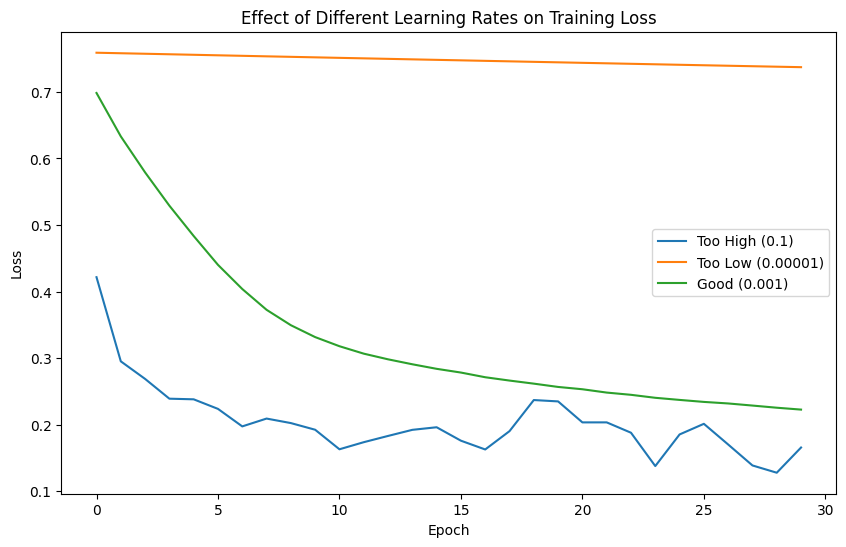

In [12]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=name
    )

plt.title("Effect of Different Learning Rates on Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()



> ### Learning Rate Experiment Analysis
>
> The experiment demonstrates how the learning rate affects the training process. With the **high learning rate**, the optimizer takes large steps when updating the weights. This can cause the loss to fluctuate or behave unstably because the model may repeatedly overshoot a good minimum.
>
> With the **very low learning rate**, the optimizer takes extremely small steps. The loss decreases more slowly, meaning that the model is learning, but training is inefficient and requires more epochs.
>
> The learning rate of **0.001** produces a more stable and efficient decrease in the loss. The optimizer takes steps that are large enough to learn efficiently while remaining small enough to avoid unstable behavior.

## Step 3: Explain, in your own words, what backpropagation computes and why the chain rule is involved.


> Backpropagation calculates the **gradient of the loss with respect to every trainable weight in the neural network**. In other words, after the network makes a prediction and calculates its error, backpropagation determines how much each weight contributed to that error.
>
> It starts from the loss and works backward through the network. The chain rule is necessary because the operations in a neural network are connected together. A weight affects the output of one neuron, that output affects the next layer, the next layer affects the final prediction, and the prediction affects the loss.
>
> The chain rule allows us to calculate how a small change in a particular weight would eventually affect the final loss, even though the weight may be several layers away from the output.
>
> The resulting gradients are then passed to the optimizer, which uses them to update the weights in a direction that reduces the loss. Therefore, backpropagation does not directly update the weights; instead, it calculates the information needed for the optimizer to perform the update.



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>

# References

- Read in depth about Gradient Descent : https://www.analyticsvidhya.com/blog/2020/10/how-does-the-gradient-descent-algorithm-work-in-machine-learning/